## Problem 1 TF-IDF

Implement TF-IDF using using Python, Numpy, Pandas and whatever text cleaning library required.

The tf–idf is the product of two statistics, term frequency and inverse document frequency. There are various ways for determining the exact values of both statistics, you can use the following formulas.

### Term Frequency
$$tf_{t,d} = \log_{10}(count(t,d) +1)$$

* $tf_{t,d}$ is the frequency of the word t in the
document d

### Inverse Document Frequency
$$idf_t = \log_{10}(\frac{N}{df_t})$$

* $N$ is the total number of documents
* $df_t $ is the number of documents in which term t occurs

### TF-IDF
$$tf\text{-}idf_{t,d} = tf_{t,d} \times idf_t $$

### What is expected?
Your implementation should include the following two functions:
 * `compute_tfidf_weights(train_docs)`
 * `word_tfidf_vector(word, tf_df, idf_df)`

To revise what TF-IDf is, you can revise the lecture notes and the further reading under Week 7.


In [1]:
# importing all the necessary libraries
import collections
import pandas as pd
import numpy as np

# this function calculates the term frequency (TF) and the inverse document frequency (IDF) weights for all the words in the input documents
def compute_tfidf_weights(train_docs):
  '''
  Input arguments:
    train_docs : list of documents, i.e., strings
  Output arguments:
    docs_tf : tf as a DataFrame
    docs_idf : idf as a DataFrame
  Note: the use of Pandas DataFrame is not mandatory
  '''
  # calculating TF weights

  # creating a dictionary to store the term frequencies for all the words
  tf_dict = collections.Counter()

  # looping over each document and update the term frequency dictionary
  for doc in train_docs:
    words = doc.split()
    tf_dict.update(words)

  # converting the term frequency dictionary to a pandas DataFrame as requested
  docs_tf = pd.DataFrame.from_dict(tf_dict, orient="index", columns=["tf"])


  # calculating the IDF weights

  # calculating the number of documents
  n_docs = len(train_docs)

  # creating a new DataFrame to store the document frequencies for all the words
  docs_df = pd.DataFrame(columns=["df"])

  # looping over each word in the term frequency dictionary and calculating the document frequency
  for word, tf in tf_dict.items():
    doc_count = 0
    for doc in train_docs:
      if word in doc:
        doc_count += 1
    docs_df.loc[word] = {"df": doc_count}

  # converting the document frequency DataFrame to a pandas DataFrame
  docs_idf = pd.DataFrame(data={"idf":np.log(n_docs / docs_df["df"]) })

  # returning the TF and IDF DataFrames as requested
  return docs_tf, docs_idf


# this function calculates the TF-IDF weight for a given input word in the set of input documents
def word_tfidf_vector(word, tf_df, idf_df):
  '''
    Input arguments:
      word : a query string
      tf_tf : tf as a DataFrame
      tf_idf : idf as a DataFrame
    Output arguments:
      tf_idf_value : a numpy array of dimension 1xN
  '''
  # checking if the tf_df is a pandas DataFrame
  if not isinstance(tf_df, pd.DataFrame):
    raise TypeError("tf_df must be a pandas DataFrame")

  # checking if the idf_df is a pandas DataFrame
  if not isinstance(idf_df, pd.DataFrame):
    raise TypeError("idf_df must be a pandas DataFrame")

  # converting the word to lowercase - just in case
  word = word.lower()

  # trying to get the TF weight for the word from the tf_df DataFrame
  try:
    tf = tf_df.loc[word, "tf"]
  except KeyError:
    # setting the TF weight to 0 if the word is not found in the tf_df DataFrame
    tf = 0

  # trying to get the IDF weight for thr word from the idf_df DataFrame
  try:
    idf = idf_df.loc[word, "idf"]
  except KeyError:
    # setting the IDF weight to 0 if the word is not found in the idf_df DataFrame
    idf = 0

  # displaying an output message when the input word does not appear in any of the input documents
  if tf == 0:
    print(f"\nThe input word '{word}' does not appear in any of the input documents")
    return np.array([[0.]])

  # calculating the TF-IDF weights when the input word appears in any of the input documents
  tf_idf_value = tf * idf

  # returning the TF-IDF weight of the input word as a numpy array of dimension 1x1
  return np.array([[tf_idf_value]])


**Implementing the above defined TF-IDF functions to calculate the TF-IDF weights for a given set of input documents**

In [2]:
#defining our input documents
documents = [
    "The quick brown fox jumps over the lazy dog.",
    "The dog barked at the fox.",
    "The fox was quick and brown."
]

docs_tf, docs_idf = compute_tfidf_weights(documents)

# computing the TF, IDF matrices

# displaying the TF weights of all the words
print("\nThe TF weights for all the words are : \n\n", docs_tf)

# displaying the IDF weights of all the words
print("\nThe IDF weights for all the words are : \n\n", docs_idf)

input_word = "quick"

tf_idf_weight = word_tfidf_vector(input_word, docs_tf, docs_idf)

print(f"\nTF-IDF weight for word '{input_word}': {tf_idf_weight}")

# computing the TF-IDF vector of an input word

input_word = "cat"

tf_idf_weight = word_tfidf_vector(input_word, docs_tf, docs_idf)

print(f"\nTF-IDF weight for word '{input_word}': {tf_idf_weight}")



The TF weights for all the words are : 

         tf
The      3
quick    2
brown    1
fox      2
jumps    1
over     1
the      2
lazy     1
dog.     1
dog      1
barked   1
at       1
fox.     1
was      1
and      1
brown.   1

The IDF weights for all the words are : 

              idf
The     0.000000
quick   0.405465
brown   0.405465
fox     0.000000
jumps   1.098612
over    1.098612
the     0.405465
lazy    1.098612
dog.    1.098612
dog     0.405465
barked  1.098612
at      1.098612
fox.    1.098612
was     1.098612
and     1.098612
brown.  1.098612

TF-IDF weight for word 'quick': [[0.81093022]]

The input word 'cat' does not appear in any of the input documents

TF-IDF weight for word 'cat': [[0.]]


## Problem 2 Word embedding as features for classification

### Task
Implement a sentiment classifier based on Twitter data to analyse the sentiments of COVID-19 tweets.  

Train and test multiple classification model using necessary libraries with the features being sentence embeddings of tweets.

Report the accuracy and F1 score (micro- and macro-averaged) for multiple classifier and discuss the differences.

### Dataset
The dataset have been provided in the first code trunk with the assignment. You are required to use the original tweet text for this classification task.

### Tweet representation
After necessary pre-processing of the tweets, convert the words into their embeddings, then take the mean of all the word vectors in a tweet to end up with a single vector representing each tweet. The tweet vector is then used for sentiment classification.

In the process of finding the embeddings for each word, you can ignore out-of-vocabulary words.  

### Classifier choice
You are required to implement the following TWO classifiers:
* One tradition classification model (not a neural network based model)
* One classifier based on any neural network based model.

You can use PyTorch/TensorFlow/scikit-learn to implement your classifier. However, you are free to develop a classifier from scratch.

### Your answer must include the following:
1. Code for data loading, data pre-processing, training, and testing of the models.  
2. A discussion on the comparison between the classifiers based on classifier accuracy and F1 score.



In [3]:
# loading the Dataset
import pandas as pd
train_data_url = "https://drive.google.com/uc?export=download&id=19JmVSOZ85vikn5aKna97aL5LM8KtG3T7"
test_data_url = "https://drive.google.com/uc?export=download&id=19EnwRfr6q5lzVB_UpJlGOG3IxgDhYVgP"

df_train = pd.read_csv(train_data_url, encoding='latin-1')[["OriginalTweet","Sentiment"]].rename(columns={'OriginalTweet': 'tweet', 'Sentiment': 'label'})
df_test = pd.read_csv(test_data_url, encoding='latin-1')[["OriginalTweet","Sentiment"]].rename(columns={'OriginalTweet': 'tweet', 'Sentiment': 'label'})

# displaying the test dataset
df_test

,tweet,label
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,When I couldn't find hand sanitizer at Fred Me...,Positive
2,Find out how you can protect yourself and love...,Extremely Positive
3,#Panic buying hits #NewYork City as anxious sh...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral
...,...,...
3793,Meanwhile In A Supermarket in Israel -- People...,Positive
3794,Did you panic buy a lot of non-perishable item...,Negative
3795,Asst Prof of Economics @cconces was on @NBCPhi...,Neutral
3796,Gov need to do somethings instead of biar je r...,Extremely Negative


**Pre-processing of the tweets in our datasets**

In [4]:
# preprocessing the data

import re
def preprocess_text(text):

  # removing the URLs
  text = re.sub(r'http\S+', ' ', text)

  # removing punctuation marks
  text = re.sub(r'[^\w\s]', ' ', text)

  # converting to lowercase
  text = text.lower()

  # removing empty spaces
  text = text.strip()

  return text


# applying preprocessing function to our training and test datasets
df_train['tweet'] = df_train['tweet'].apply(preprocess_text)
df_test['tweet'] = df_test['tweet'].apply(preprocess_text)

# removing duplicate tweets if any
df_train = df_train.drop_duplicates(subset= 'tweet')
df_test = df_test.drop_duplicates(subset='tweet')

# removing empty tweets if any
df_train = df_train[df_train['tweet'].str.len() > 0]
df_test = df_test[df_test['tweet'].str.len() > 0]

# displaying the preprocessed data
print("Pre-processed Training dataset : \n", df_train.head())
print("\nPre-processed Testing dataset : \n", df_test.head())




Pre-processed Training dataset : 
                                                tweet               label
0         menyrbie  phil_gahan  chrisitv   and   and             Neutral
1  advice talk to your neighbours family to excha...            Positive
2  coronavirus australia  woolworths to give elde...            Positive
3  my food stock is not the only one which is emp...            Positive
4  me  ready to go at supermarket during the  cov...  Extremely Negative

Pre-processed Testing dataset : 
                                                tweet               label
0  trending  new yorkers encounter empty supermar...  Extremely Negative
1  when i couldn t find hand sanitizer at fred me...            Positive
2  find out how you can protect yourself and love...  Extremely Positive
3  panic buying hits  newyork city as anxious sho...            Negative
4  toiletpaper  dunnypaper  coronavirus  coronavi...             Neutral


In [5]:
#df_train.info()
#df_test.info()

# displaying the class distribution of our training and test datasets
print("Training dataset's class distribution: ", df_train['label'].value_counts())
print("\nTest dataset's class distribution: ", df_test['label'].value_counts())

Training dataset's class distribution:  label
Positive              11403
Negative               9904
Neutral                7687
Extremely Positive     6622
Extremely Negative     5478
Name: count, dtype: int64

Test dataset's class distribution:  label
Negative              1041
Positive               947
Neutral                618
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64


In [6]:
# ordinal encoding of class variables for avoiding multi-label class issues
from sklearn.preprocessing import OrdinalEncoder

# defining the list of class labels
class_labels = ['Extremely Negative', 'Negative', 'Neutral', 'Positive', 'Extremely Positive']

# creating an instance of the OrdinalEncoder class
# the 'categories' parameter specifies the possible values for the class variable
encoder = OrdinalEncoder(categories=[class_labels])

# using the encoder to transform the 'label' column of the training and test datasets
df_train['label'] = encoder.fit_transform(df_train['label'].values.reshape(-1,1))
df_test['label'] = encoder.fit_transform(df_test['label'].values.reshape(-1,1))

# displaying the class distribution of our training and test datasets to check the results of encoding
print("Training dataset's class distribution: ", df_train['label'].value_counts())
print("\nTest dataset's class distribution: ", df_test['label'].value_counts())

Training dataset's class distribution:  label
3.0    11403
1.0     9904
2.0     7687
4.0     6622
0.0     5478
Name: count, dtype: int64

Test dataset's class distribution:  label
1.0    1041
3.0     947
2.0     618
4.0     599
0.0     592
Name: count, dtype: int64


In [7]:
# tokenizing the tweets to normalize the text

# importing the libraries needed
import nltk
#nltk.download('punkt') # punkt is already downloaded
from nltk.tokenize import word_tokenize

# Downloading punkt_tab resource
nltk.download('punkt_tab')


# tokenizing the tweets in both the training and test datasets
df_train['tweet'] = df_train['tweet'].apply(word_tokenize)
df_test['tweet'] = df_test['tweet'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
# removing stop words from the training and test datasets to improve the performance of sentiment analysis models

# downloading the list of stop words
nltk.download('stopwords')
from nltk.corpus import stopwords

# creating a set of stop words
stop_words = set(stopwords.words('english'))

# removing the stop words from our training and test datasets
df_train['tweet'] = df_train['tweet'].apply(lambda x: [word for word in x if word not in stop_words])
df_test['tweet'] = df_test['tweet'].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Generation of tweet level embedding using Word2Vec model**

In [9]:
# generating the tweet level embeddings using Word2Vec model

# importing the necessary libraries
import gensim
from gensim.models import Word2Vec
import numpy as np

# creating a Word2Vec model
model = Word2Vec(df_train['tweet'], vector_size=100, window=5, min_count=1, workers=8)

# generating the tweet-level embeddings by calculating the mean of all the words in a tweet
#this function takes in the tweets and the Word2Vec model defined above to generate the tweet embeddings
def generate_tweet_embeddings(tweets, model):
  tweet_embeddings = []

  # looping over all the tweets
  for tweet in tweets:
    # initializing the tweet embeddings as a zero vector
    tweet_embedding = np.zeros(model.vector_size)

    # keeping track of the number of words in the tweet
    word_count = 0

    # looping over each word in the tweet
    for word in tweet:
      if word in model.wv.key_to_index:

        # adding the word embedding to the tweet embedding
        tweet_embedding += model.wv[word]

        # incrementing the word count
        word_count += 1

    # calculating the average embedding if there are any words in the tweet
    if word_count > 0:
      tweet_embedding /= word_count

    # appending the tweet embedding to the list
    tweet_embeddings.append(tweet_embedding)

  # returning the list of tweet embeddings
  return tweet_embeddings

# calling in the above function to generate tweet-level embeddings for the training and test datasets
train_embeddings = generate_tweet_embeddings(df_train['tweet'], model)
test_embeddings = generate_tweet_embeddings(df_test['tweet'], model)


In [10]:
!pip install gensim

In [11]:
# generating the tweet level embeddings using Word2Vec model

# importing the necessary libraries
import gensim
from gensim.models import Word2Vec
import numpy as np

# creating a Word2Vec model
model = Word2Vec(df_train['tweet'], vector_size=100, window=5, min_count=1, workers=8)

# generating the tweet-level embeddings by calculating the mean of all the words in a tweet
#this function takes in the tweets and the Word2Vec model defined above to generate the tweet embeddings
def generate_tweet_embeddings(tweets, model):
  tweet_embeddings = []

  # looping over all the tweets
  for tweet in tweets:
    # initializing the tweet embeddings as a zero vector
    tweet_embedding = np.zeros(model.vector_size)

    # keeping track of the number of words in the tweet
    word_count = 0

    # looping over each word in the tweet
    for word in tweet:
      if word in model.wv.key_to_index:

        # adding the word embedding to the tweet embedding
        tweet_embedding += model.wv[word]

        # incrementing the word count
        word_count += 1

    # calculating the average embedding if there are any words in the tweet
    if word_count > 0:
      tweet_embedding /= word_count

    # appending the tweet embedding to the list
    tweet_embeddings.append(tweet_embedding)

  # returning the list of tweet embeddings
  return tweet_embeddings

# calling in the above function to generate tweet-level embeddings for the training and test datasets
train_embeddings = generate_tweet_embeddings(df_train['tweet'], model)
test_embeddings = generate_tweet_embeddings(df_test['tweet'], model)

**Implementation of a traditional Classifier - Logistic Regression model**

In [12]:
# implementing a traditional classifier
# let us implement a Logistic Regression model on our datasets

# importing the necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# standardizing the tweet embeddings to improve the performance, as the dataset is an imbalanced one
scaler = StandardScaler()
scaled_train_embeddings = scaler.fit_transform(train_embeddings)
scaled_test_embeddings = scaler.transform(test_embeddings)

# creating a Logistic Regression object using the parameters 'max_iter', which specifies the maximum number of iterations for the model training
# and 'C', which specifies the regularization strength.
model = LogisticRegression(max_iter=1000, C=0.1)

# training the model using the generated tweet embeddings
# 'fit' method trains the model using the scaled training embeddings and the labels from the training data
model.fit(scaled_train_embeddings, df_train['label'])

# making predictions on the test data
predictions = model.predict(scaled_test_embeddings)


The accuracy score of our logistic regression model is : 0.37740321306294444

f1_score of our Logistic Regression model is :  0.37740321306294444


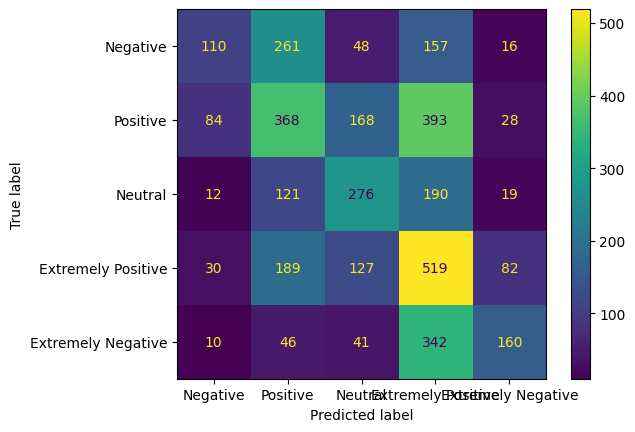


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.45      0.19      0.26       592
         1.0       0.37      0.35      0.36      1041
         2.0       0.42      0.45      0.43       618
         3.0       0.32      0.55      0.41       947
         4.0       0.52      0.27      0.35       599

    accuracy                           0.38      3797
   macro avg       0.42      0.36      0.36      3797
weighted avg       0.40      0.38      0.37      3797



In [13]:
# evaluating the model performance by calculating the performance metrics

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

accuracy_score = accuracy_score(df_test['label'], predictions)
f1_score = f1_score(df_test['label'],predictions, average = 'micro')
confusion_matrix = confusion_matrix(df_test['label'], predictions)

print("The accuracy score of our logistic regression model is :", accuracy_score)
print("\nf1_score of our Logistic Regression model is : ", f1_score)

# displaying the confusion matrix on the testing data
from sklearn import metrics
import matplotlib.pyplot as plt
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['Negative', 'Positive', 'Neutral', 'Extremely Positive', 'Extremely Negative'])

cm_display.plot()
plt.show()

# displaying the classification report of our Logistic Regression model to look at the other metrics
from sklearn.metrics import classification_report
print("\nClassification Report: ")
print(classification_report(df_test['label'], predictions))


**Implementation of a Neural Network based classifier - using a simple Feed Forward Neural Network Model**

In [14]:
# implementing a neural network based classifier
# implementing a simple Feed Forward Neural Network Model with one hidden layer and a softmax output layer
# on our training and test embeddings

# importing the necessary libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.regularizers import l2

# converting the train_embeddings and test_embeddings lists to numpy arrays
train_embeddings = np.array(train_embeddings)
test_embeddings = np.array(test_embeddings)

# defining the input layer
inputs = Input(shape=(train_embeddings.shape[1],))

# defining the hidden layer, with a kernel_regularizer to prevent overfitting and improve the accuracy
dense1 = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(inputs)

# defining another hidden layer as the accuracy is poor (got around 37%) with only a single hidden layer
dense2 = Dense(16, activation='tanh')(dense1)

# defining the output layer
outputs = Dense(5, activation='softmax')(dense2)

# creating the model
classifier2_model = tf.keras.Model(inputs=inputs, outputs=outputs)

# compiling the model
classifier2_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



# training the model using the training data, using more epochs to allow the model to learn from the data and improve the accuracy
hist = classifier2_model.fit(train_embeddings, df_train['label'], epochs=25)

# predicting the results on test data
predicted_labels = np.argmax(classifier2_model.predict(test_embeddings), axis=1)

# evaluating the model
loss, accuracy = classifier2_model.evaluate(test_embeddings, df_test['label'])
print("\nThe accuracy score of our Feed Forward Neural Network model is : ", accuracy)

#displaying the f1_score
print("\nThe f1_score of our classifier2_model is : ", f1_score)

# displaying the classification report of our Logistic Regression model to look at the other metrics
from sklearn.metrics import classification_report
print("\nClassification Report: ")

# displaying the classification report
print(classification_report(df_test['label'], predicted_labels))

Epoch 1/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3274 - loss: 1.6324
Epoch 2/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3609 - loss: 1.4590
Epoch 3/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3666 - loss: 1.4372
Epoch 4/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3726 - loss: 1.4347
Epoch 5/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3767 - loss: 1.4307
Epoch 6/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3773 - loss: 1.4204
Epoch 7/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3761 - loss: 1.4190
Epoch 8/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3821 - loss: 1.4173
Epoch 9/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3793 - loss: 1.4178
Epoch 10/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3799 - loss: 1.4150
Epoch 11/25
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3753 - loss: 1.4194
Epoch 12/25
1285/1285 ━━━━━━━━

**Experimenting with an alternative approach using TF-IDF vectorizer to implement a logistic regression classifier, to find out if we can get a better accuracy score**


In [15]:
# importing the necessary libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

df_train['tweet'] = df_train['tweet'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df_test['tweet'] = df_test['tweet'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# creating the pipeline
classifier3_model = Pipeline([
    ('tfidf', TfidfVectorizer(min_df =2, max_features=100000)),
    ('LogisticRegression', LogisticRegression(solver='sag'))
])

# fitting the pipeline to the data
classifier3_model.fit(df_train['tweet'], df_train['label'])

#training the model
prediction3 = classifier3_model.predict_proba(df_test['tweet'])

# predicting on the test datset
#prediction_int = prediction [:, 1] >= 0.3

# if the prediction is greater than or equal to 0.3 then 1 else 0
#prediction_int = prediction_int.astype(int)

prediction3 = np.argmax(prediction3, axis=1)

f1_score for our Logistic Regression model is :  0.5604424545693969

accuracy_Score for our Logistic Regression model is :  0.5604424545693969


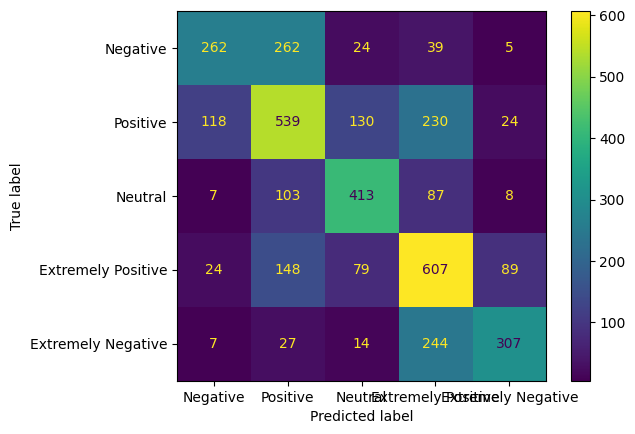


Classification Report: 
              precision    recall  f1-score   support

         0.0       0.63      0.44      0.52       592
         1.0       0.50      0.52      0.51      1041
         2.0       0.63      0.67      0.65       618
         3.0       0.50      0.64      0.56       947
         4.0       0.71      0.51      0.59       599

    accuracy                           0.56      3797
   macro avg       0.59      0.56      0.57      3797
weighted avg       0.57      0.56      0.56      3797



In [16]:
# evaluating the performance metrics
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

f1_score3 = f1_score(df_test['label'],prediction3, average = 'micro')
accuracy_score3 = accuracy_score(df_test['label'], prediction3)
confusion_matrix3 = confusion_matrix(df_test['label'], prediction3)

print("f1_score for our Logistic Regression model is : ", f1_score3)
print("\naccuracy_Score for our Logistic Regression model is : ", accuracy_score3)

# displaying the confusion matrix on the testing data
from sklearn import metrics
import matplotlib.pyplot as plt
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix3, display_labels = ['Negative', 'Positive', 'Neutral', 'Extremely Positive', 'Extremely Negative'])

cm_display.plot()
plt.show()

from sklearn.metrics import classification_report
print("\nClassification Report: ")
print(classification_report(df_test['label'], prediction3))

**Discussion on differences in performance measures**

We can see that the Logistic Regression model and the feed forward neural network model have the same accuaracy and f1_scores. This suggests that these two models perform similarly on our dataset.

The traditional classifier model using Logistic Regression achieved moderate accuracy and f1_Score of 38%. From the classification report of this model, we can see that the model performs best on class 2 (Neutral class with f1_score of 0.44) and worst on class 0 (Negative) with f1_score of 0.26. The model also has relatively low recall for classes 0, 1, 4 which means that it is not very good at correctly identifying these classes. Overall, this model’s performance is not very good, as evidenced by the low f1_scores across all the classes. This could be due to several factors like the model not trained on enough data, may not be using the right features and algorithm.

The accuracy and f1_scores for the second classifier using a feed forward neural network model is 35%, which is like the traditional one. However, the classification report shows that the feed forward neural network model may be better at correctly identifying classes 2 and 3, but worse at correctly identifying classes 0, 1, 2, and 4.

We also implemented one more classifier model using logistic regression with TFIDF vectorizer, to convert the text data into a numerical representation using the TF-IDF algorithm. The accuracy and f1_score for this model is at 56%, which means that the model correctly classified 56% of the samples in our dataset. This is a relatively good score but can be improved. Looking at the report, we can see that the model performs best on class 2 and worst on class 1.

We can improve the model's performance by collecting more data, experimenting with different features, and tuning the hyperparameters of the algorithms.

## Problem 3 POS for classification

Robots and chat bots receive different commands to do certain tasks.

Write a simple pragram that receive interactions in the form of a sentence and return:
* A tuple of (command, object) (eg. (Grab, book)) if the sentence is a command
* None if the sentence is not a command

To write this function, you can utilize a Part-of-speech tagger or named-entity recognizer from libraries like NLTK and Spacy.

Consider the following EXAMPLE sentences:

* Commands:
  * Grab the book
  * Fetch the ball
  * Open the jar
  

* Not commands:
  * Hey, how is it going?
  * How is your day today?
  * Do you like the weather?

This list is not exhaustive, your function should be able to handle more cases.

Expected outcome:

1. A function that performs the task
2. Test the function with the above provided (Commands / Not Commands) examples and print the output  

In [17]:
# downloading the packages required to execute our function
!python -m nltk.downloader words
!python -m nltk.downloader punkt
!python -m nltk.downloader averaged_perceptron_tagger_eng

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       dat

In [18]:
# importing the necessary libraries
import nltk
import re

# this function will take a sentence as input parameter and then displays if the sentence is a command or not
# and also displays the command and the object if it is.
def extract_command(sentence):

  # tokenizing the sentence and perform POS tagging
  tokens = nltk.word_tokenize(sentence)
  pos_tags = nltk.pos_tag(tokens)

  # checking if the first word of the example sentence is a verb
  if pos_tags[0][1].startswith('VB') and sentence.count('?') == 0:

    # checking if the sentence is in the imperative mood
    if pos_tags[0][0].lower() in ['please', 'can you', 'could you', 'will you', 'would you']:
      return None

    # checking if the sentence contains a performative verb
    performative_verbs = ['order', 'command', 'request', 'ask']
    if pos_tags[0][0].lower() in performative_verbs:
      return None

    # extracting the verb and the object
    verb = pos_tags[0][0]
    obj = None
    for i in range(1, len(pos_tags)):
      if pos_tags[i][1].startswith(('NN', 'NNS', 'NNP', 'NNPS')):
        obj = pos_tags[i][0]
        break

    # if both a verb and an object are found, return the command
    if verb and obj:
      return (verb, obj)
    else:
      return None

  # otherwise, return None
  return None


# Testing the function with the given example sentences
sentences = ["Grab the book",
             "Fetch the ball",
             "Open the jar",
             "Hey, how is it going?",
             "How is your day today?",
             "Get me a glass of water",
             "Open the jar and pour the contents",
             "Do you like the weather?"
             ]

for sentence in sentences:
  command = extract_command(sentence)

  # displaying the command and object in the sentence if it is a command
  if command:
    print("Sentence is : ", sentence)
    print("Command is : ", command[0])
    print("Object is : ", command[1])
    print()
  # displaying the sentence only, if it isn't a command
  else:
    print("Sentence is : ", sentence)
    print("Not a command")
    print()


Sentence is :  Grab the book
Command is :  Grab
Object is :  book

Sentence is :  Fetch the ball
Command is :  Fetch
Object is :  ball

Sentence is :  Open the jar
Command is :  Open
Object is :  jar

Sentence is :  Hey, how is it going?
Not a command

Sentence is :  How is your day today?
Not a command

Sentence is :  Get me a glass of water
Command is :  Get
Object is :  glass

Sentence is :  Open the jar and pour the contents
Command is :  Open
Object is :  jar

Sentence is :  Do you like the weather?
Not a command

